# Cobertura HPO em português
Notebook de inspeção do snapshot versionado usado pelo HPO-PTBR Lab.


In [1]:
import json
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
summary = json.loads((ROOT / 'data/processed/coverage_summary.json').read_text(encoding='utf-8'))
summary


{'data_version': 'hpo-2026-06-23_pt-62f1d254',
 'hpo_release': '2026-06-23',
 'translation_commit': '62f1d254f93e47d87e874783019ccd7480400e76',
 'generated_at': '2026-07-14T17:30:04.837716+00:00',
 'active_terms': 19836,
 'translated_labels_pt': 7158,
 'translated_definitions_pt': 1,
 'label_coverage_percent': 36.09,
 'sources': {'hpo': {'url': 'https://github.com/obophenotype/human-phenotype-ontology/releases/latest/download/hp.json',
   'sha256': '3b646565695329aa399e937883c68d5d424d0df5eaab2f22baa0e08d44fdbe87'},
  'hpo_pt': {'url': 'https://raw.githubusercontent.com/obophenotype/hpo-translations/main/babelon/hp-pt.babelon.tsv',
   'commit': '62f1d254f93e47d87e874783019ccd7480400e76',
   'sha256': '31f642ef8f6951287d9386d3b3454990504143520161ef4615c1c5c0ed85ebd0'}}}

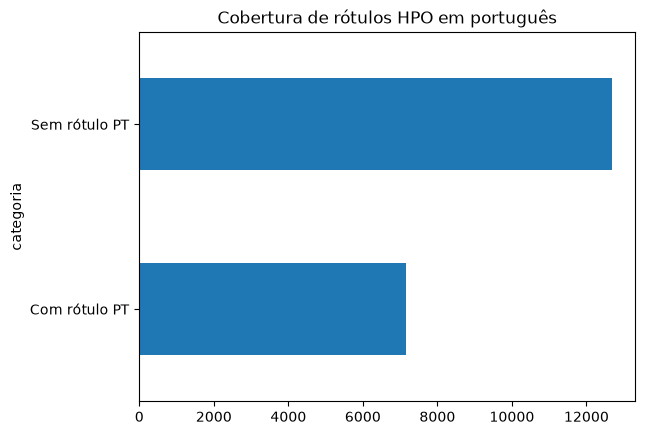

In [2]:
coverage = pd.DataFrame({
    'categoria': ['Com rótulo PT', 'Sem rótulo PT'],
    'termos': [summary['translated_labels_pt'], summary['active_terms'] - summary['translated_labels_pt']],
})
coverage.set_index('categoria').plot.barh(legend=False, title='Cobertura de rótulos HPO em português');


In [3]:
missing = pd.read_csv(ROOT / 'data/processed/untranslated_terms.csv')
missing.head(20)


,hpo_id,label_en
0,HP:0000117,Renal phosphate wasting
1,HP:0000216,Broad secondary alveolar ridge
2,HP:0000245,Abnormal paranasal sinus morphology
3,HP:0000309,Abnormal midface morphology
4,HP:0000365,Hearing impairment
5,HP:0000589,Coloboma
6,HP:0000617,Abnormality of ocular smooth pursuit
7,HP:0000629,Periorbital fullness
8,HP:0000630,Abnormal retinal arterial/arteriolar morphology
9,HP:0000641,Dysmetric saccades
